# Context

In this notebook we will 

# Load packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

c:\Users\57315\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\57315\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


# Load data

using relative paths

In [2]:
filename = "modelling_regression.ipynb"  # Current file name
print(f"Current file name: {filename}\n")
print(f"Current absolute path: {os.getcwd()}\n")

# Specify the paths, relative to the current file
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output_data")

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Current file name: modelling_regression.ipynb

Current absolute path: c:\Users\57315\Documents\ICESI\SEMESTRE_I\APRENDIZAJE_AUTOMATICO_I\TRABAJO FINAL\Proyecto_Final_Caña\ML1_sugar_industry\notebooks

BASE_DIR: c:\Users\57315\Documents\ICESI\SEMESTRE_I\APRENDIZAJE_AUTOMATICO_I\TRABAJO FINAL\Proyecto_Final_Caña\ML1_sugar_industry
DATA_DIR: c:\Users\57315\Documents\ICESI\SEMESTRE_I\APRENDIZAJE_AUTOMATICO_I\TRABAJO FINAL\Proyecto_Final_Caña\ML1_sugar_industry\data
OUTPUT_DIR: c:\Users\57315\Documents\ICESI\SEMESTRE_I\APRENDIZAJE_AUTOMATICO_I\TRABAJO FINAL\Proyecto_Final_Caña\ML1_sugar_industry\data\output_data


In [3]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "suertes_for_reg.csv")).iloc[:, 1:]

df.head(5)

,tch,pct_sac_caña,zona,dist_km,cult_organico,num_cosechas,edad_ult_cos,edad_precosecha,vejez,pct_infest_diatrea,dosis_madurante,semanas_mad_,ddult_riego,num_riegos,lluvias_2_meses_ant_,lluvias_0__3,lluvias_tres_a_seis,lluvias_seis_a_nueve,lluvias_9_a_cos,lluvias_ciclo,tipo_quema,t_corte,temp__media_0_3,temp__media_ciclo,temp_max_ciclo,temp_min_ciclo,humedad_rel_media_0_3,humedad_rel_media_ciclo,oscilacion_temp_med_0_3,oscilacion_temp_ciclo,radicion_solar_0_3,radiacion_solar_ciclo,precipitacion_0_3,precipitacion_ciclo,evaporacion_0_3,evaporacion_ciclo,urea_46pct_,mez,boro_granul_,microzinc,nito_xtend,sul_amonio,nitrax_s,rango_edad_ult_cos,m3_riego_p_ha,edad_siembra_a_ult_cos,variedad_v2,producto_categoria,algun_fertilizante,agua_total_l_ha,vinaza_p_ha
0,149.714285,9.9300,ip06,7.5,0.0,1,12.68,11.27,NaN,NaN,NaN,NaN,148.0,1.0,192.0,110.0,369.0,103.0,403.0,985.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.730159,39.682540,NaN,NaN,NaN,NaN,NaN,11-12 meses,2054.285714,21.618070,cc_mayor_2000,No especificado,1,1.190429e+07,8730.158730
1,129.673316,10.7856,ip06,7.5,0.0,8,12.02,10.58,15.540,NaN,NaN,NaN,103.0,3.0,192.0,190.0,309.0,168.0,314.0,981.0,q_programada,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149.625935,49.875312,19.950125,19.950125,NaN,NaN,NaN,11-12 meses,4977.680798,114.398357,cc_menor_2000,No especificado,1,1.478768e+07,2244.389027
2,139.855072,11.5614,ip06,7.5,0.0,1,12.48,10.81,1.930,NaN,1.0,6.571428,133.0,2.0,172.0,180.0,307.0,149.0,345.0,981.0,verde,mecanizado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.618357,48.309179,NaN,NaN,NaN,NaN,NaN,11-12 meses,2383.130435,23.260780,cc_mayor_2000,Madurante,1,1.219313e+07,NaN
3,157.754901,10.9520,ip06,7.5,0.0,3,12.09,10.68,10.312,NaN,1.0,5.428571,114.0,4.0,298.0,348.0,345.0,182.0,476.0,1351.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147.058824,49.019608,NaN,NaN,NaN,NaN,NaN,11-12 meses,10912.045752,41.626283,others,Madurante,1,2.442205e+07,3921.568627
4,127.289256,9.3950,ip06,7.5,0.0,1,12.12,10.71,NaN,NaN,NaN,NaN,89.0,5.0,149.0,280.0,308.0,152.0,298.0,1038.0,verde,manual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11-12 meses,7757.000000,23.556468,cc_menor_2000,No especificado,0,1.813700e+07,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20126 entries, 0 to 20125
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tch                      20126 non-null  float64
 1   pct_sac_caña             19971 non-null  float64
 2   zona                     20126 non-null  object 
 3   dist_km                  20121 non-null  float64
 4   cult_organico            20124 non-null  float64
 5   num_cosechas             20126 non-null  int64  
 6   edad_ult_cos             20126 non-null  float64
 7   edad_precosecha          8745 non-null   float64
 8   vejez                    17963 non-null  float64
 9   pct_infest_diatrea       5470 non-null   float64
 10  dosis_madurante          13629 non-null  float64
 11  semanas_mad_             13629 non-null  float64
 12  ddult_riego              12547 non-null  float64
 13  num_riegos               12542 non-null  float64
 14  lluvias_2_meses_ant_  

# **APLICACION DE RIDGE Y LASSO PARA TCH**

In [5]:
# Separar variables predictoras y objetivo
X = df.drop(columns=["tch"])
y = df["tch"]

In [6]:
# 1. DIVISION DE LOS DATOS
# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [7]:
#2. PREPROCESAMIENTO MANUAL
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identificar columnas categóricas
cat_cols = ['zona', 'tipo_quema', 't_corte', 'rango_edad_ult_cos', 'variedad_v2', 'producto_categoria']
num_cols = [col for col in X.columns if col not in cat_cols]

In [8]:
# Codificación categórica
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

X_train_cat = pd.DataFrame(
    encoder.transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

In [9]:
# Escalado de variables numéricas
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train_num = pd.DataFrame(
    scaler.transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

In [10]:
# Concatenar todo
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

In [11]:
# 3. ELIMINAR VARIABLES CON >60% NULOS + IMPUTAR RESTO

from sklearn.impute import SimpleImputer

# Identificar columnas con >60% de nulos
threshold = 0.6
nan_fraction = X_train_processed.isna().mean()
cols_to_drop = nan_fraction[nan_fraction > threshold].index.tolist()

In [12]:
# Eliminar columnas
X_train_clean = X_train_processed.drop(columns=cols_to_drop)
X_test_clean = X_test_processed.drop(columns=cols_to_drop)

In [13]:
# Imputar el resto con la media
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns, index=X_train_clean.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test_clean.columns, index=X_test_clean.index)

In [14]:
# 4. GRIDSEARCHCV PARA RIDGE Y LASSO

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# Definir grids
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

In [15]:
# Instancias
ridge = Ridge()
lasso = Lasso(max_iter=100)

In [16]:
# GridSearch Ridge
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_imputed, y_train)

# GridSearch Lasso
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_imputed, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=100),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [17]:
# Mostrar mejores alphas
print("Mejor alpha para Ridge:", ridge_grid.best_params_['alpha'])
print("Mejor alpha para Lasso:", lasso_grid.best_params_['alpha'])

mejor_alpha_ridge = ridge_grid.best_params_['alpha']
mejor_alpha_lasso = lasso_grid.best_params_['alpha']

Mejor alpha para Ridge: 10
Mejor alpha para Lasso: 0.01


In [ ]:
# Entrenamiento y Evaluación Final con Ridge y Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Entrenar modelos con los mejores alphas
ridge_best = Ridge(alpha=mejor_alpha_ridge)
lasso_best = Lasso(alpha=mejor_alpha_lasso, max_iter=10000)

ridge_best.fit(X_train_imputed, y_train)
lasso_best.fit(X_train_imputed, y_train)

In [ ]:
# Predicciones
ridge_pred = ridge_best.predict(X_test_imputed)
lasso_pred = lasso_best.predict(X_test_imputed)

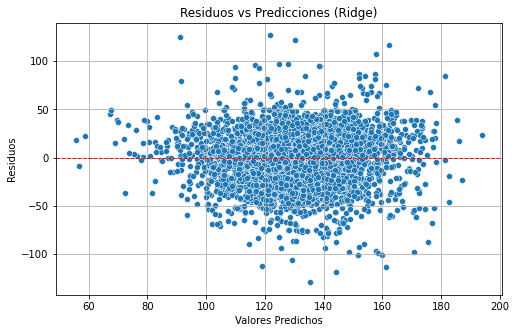

In [ ]:
# Gráfico de residuos vs predicciones (linealidad y homoscedasticidad)

residuos = y_test - ridge_pred  # Residuos para Ridge

plt.figure(figsize=(8, 5))
sns.scatterplot(x=ridge_pred, y=residuos)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuos vs Predicciones (Ridge)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()


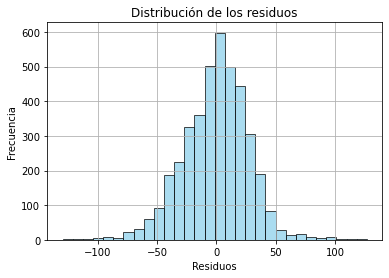

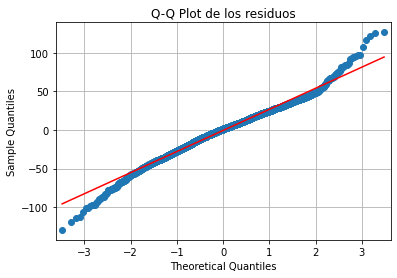

In [ ]:
# Histograma y Q-Q plot de residuos (normalidad) Ridge

y_test_array = np.array(y_test, dtype='float64').flatten()
y_pred_array = np.array(ridge_pred, dtype='float64').flatten()

# Calcular residuos
residuos = y_test_array - y_pred_array

plt.figure(figsize=(6, 4))
plt.hist(residuos, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

import statsmodels.api as sm

sm.qqplot(residuos, line='s')
plt.title("Q-Q Plot de los residuos")
plt.grid(True)
plt.show()

In [ ]:
# Gráfico de residuos vs predicciones (linealidad y homoscedasticidad)

residuos = y_test - lasso_pred  # Residuos para Lasso

plt.figure(figsize=(8, 5))
sns.scatterplot(x=lasso_pred, y=residuos)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuos vs Predicciones (Lasso)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()

ValueError: operands could not be broadcast together with shapes (3993,) (4026,) 

In [ ]:
# Histograma y Q-Q plot de residuos (normalidad) Lasso

y_test_array = np.array(y_test, dtype='float64').flatten()
y_pred_array = np.array(lasso_pred, dtype='float64').flatten()

# Calcular residuos
residuos = y_test_array - y_pred_array

plt.figure(figsize=(6, 4))
plt.hist(residuos, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

import statsmodels.api as sm

sm.qqplot(residuos, line='s')
plt.title("Q-Q Plot de los residuos Lasso")
plt.grid(True)
plt.show()

ValueError: operands could not be broadcast together with shapes (3993,) (4026,) 

In [ ]:
# Función para métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [ ]:
# Calcular métricas
ridge_mae, ridge_rmse, ridge_r2 = calcular_metricas(y_test, ridge_pred)
lasso_mae, lasso_rmse, lasso_r2 = calcular_metricas(y_test, lasso_pred)

In [ ]:
# Tabla comparativa final
resultados_finales = pd.DataFrame({
    'Modelo': ['Ridge', 'Lasso'],
    'Alpha óptimo': [mejor_alpha_ridge, mejor_alpha_lasso],
    'MAE': [ridge_mae, lasso_mae],
    'RMSE': [ridge_rmse, lasso_rmse],
    'R²': [ridge_r2, lasso_r2]
})

print(resultados_finales)

  Modelo  Alpha óptimo        MAE       RMSE        R²
0  Ridge         10.00  20.984377  27.338149  0.295247
1  Lasso          0.01  20.985710  27.336704  0.295322


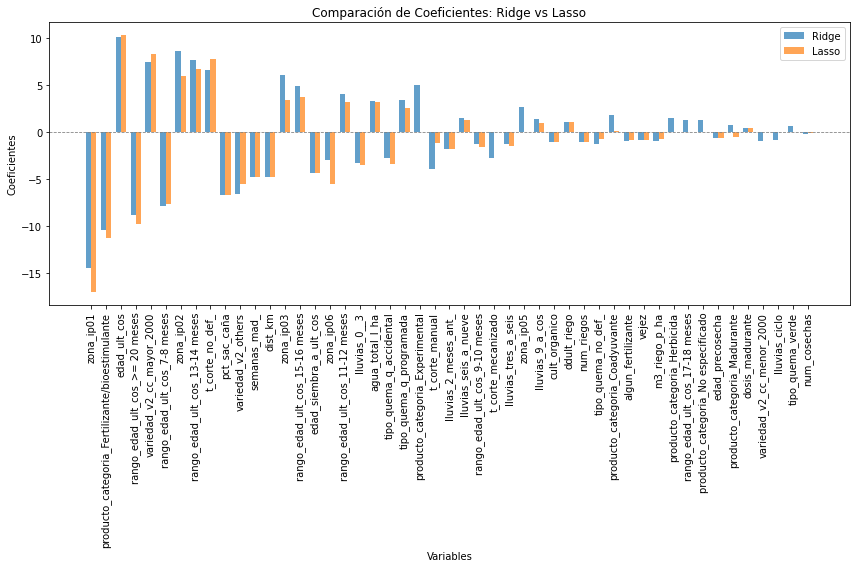

In [ ]:
# Crear DataFrame con los coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train_imputed.columns,
    'Ridge': ridge_best.coef_,
    'Lasso': lasso_best.coef_
})

# Ordenar por magnitud absoluta promedio de los coeficientes
coef_df['abs_mean'] = coef_df[['Ridge', 'Lasso']].abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values(by='abs_mean', ascending=False)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 8))
index = np.arange(len(coef_df_sorted))
bar_width = 0.35

ax.bar(index, coef_df_sorted['Ridge'], bar_width, label='Ridge', alpha=0.7)
ax.bar(index + bar_width, coef_df_sorted['Lasso'], bar_width, label='Lasso', alpha=0.7)

ax.set_xlabel('Variables')
ax.set_ylabel('Coeficientes')
ax.set_title('Comparación de Coeficientes: Ridge vs Lasso')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(coef_df_sorted['Variable'], rotation=90)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Crear DataFrame con coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train_imputed.columns,
    'Coef_Ridge': ridge_best.coef_,
    'Coef_Lasso': lasso_best.coef_
})

# Calcular magnitud media absoluta para ordenar
coef_df['AbsMedia'] = coef_df[['Coef_Ridge', 'Coef_Lasso']].abs().mean(axis=1)

# Ordenar de mayor a menor
coef_df_sorted = coef_df.sort_values(by='AbsMedia', ascending=False).reset_index(drop=True)

# Mostrar las primeras filas
print(coef_df_sorted.head(50))


                                          Variable  Coef_Ridge  Coef_Lasso  \
0                                        zona_ip01  -14.421980  -17.023437   
1   producto_categoria_Fertilizante/bioestimulante  -10.388116  -11.284170   
2                                     edad_ult_cos   10.130851   10.325241   
3                   rango_edad_ult_cos_>= 20 meses   -8.798734   -9.758166   
4                        variedad_v2_cc_mayor_2000    7.448498    8.363421   
5                     rango_edad_ult_cos_7-8 meses   -7.915118   -7.645557   
6                                        zona_ip02    8.694914    6.034899   
7                   rango_edad_ult_cos_13-14 meses    7.692057    6.739683   
8                                  t_corte_no_def_    6.586208    7.750355   
9                                     pct_sac_caña   -6.741171   -6.710467   
10                              variedad_v2_others   -6.536147   -5.536120   
11                                    semanas_mad_   -4.803511  

In [ ]:
# Crear DataFrame con coeficientes de Lasso que fueron eliminados
coef_df = pd.DataFrame({
    'Variable': X_train_imputed.columns,
    'Coef_Lasso': lasso_best.coef_
})

# Filtrar variables eliminadas por Lasso
variables_eliminadas = coef_df[coef_df['Coef_Lasso'] == 0].reset_index(drop=True)

# Mostrar
print(variables_eliminadas.head(50))

                             Variable  Coef_Lasso
0                       lluvias_ciclo         0.0
1                           zona_ip05        -0.0
2                  t_corte_mecanizado         0.0
3      rango_edad_ult_cos_17-18 meses        -0.0
4           variedad_v2_cc_menor_2000        -0.0
5     producto_categoria_Experimental         0.0
6        producto_categoria_Herbicida         0.0
7  producto_categoria_No especificado         0.0


# **USO DE RIDGE + POLYNOMIAL FEATURES**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. Crear variables polinómicas (grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_imputed)
X_test_poly = poly.transform(X_test_imputed)

# 2. GridSearchCV para Ridge
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_poly, y_train)

# 3. Predicciones con mejor modelo
ridge_poly = ridge_grid.best_estimator_
y_pred_poly_ridge = ridge_poly.predict(X_test_poly)

# 4. Métricas
mae = mean_absolute_error(y_test, y_pred_poly_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge))
r2 = r2_score(y_test, y_pred_poly_ridge)

# 5. Mostrar resultados
print("Ridge + PolynomialFeatures (grado 2) con GridSearchCV")
print(f"Alpha óptimo: {ridge_grid.best_params_['alpha']}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


Ridge + PolynomialFeatures (grado 2) con GridSearchCV
Alpha óptimo: 100
MAE:  19.9286
RMSE: 26.1703
R²:   0.3542


# **USO DE LASSO + POLYNOMIAL FEATURES**

In [ ]:
# 1. Crear variables polinómicas (grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_imputed)
X_test_poly = poly.transform(X_test_imputed)

# 2. GridSearchCV para Lasso
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=100), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_poly, y_train)

# 3. Predicciones con mejor modelo
lasso_poly = lasso_grid.best_estimator_
y_pred_poly_lasso = lasso_poly.predict(X_test_poly)

# 4. Métricas
mae = mean_absolute_error(y_test, y_pred_poly_lasso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly_lasso))
r2 = r2_score(y_test, y_pred_poly_lasso)

# 5. Mostrar resultados
print("Lasso + PolynomialFeatures (grado 2) con GridSearchCV")
print(f"Alpha óptimo: {lasso_grid.best_params_['alpha']}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


Lasso + PolynomialFeatures (grado 2) con GridSearchCV
Alpha óptimo: 0.1
MAE:  20.0507
RMSE: 26.2572
R²:   0.3499


In [ ]:
# 6. COMPARACIÓN FINAL

def evaluar_modelo(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

resultados = [
    evaluar_modelo("Ridge", y_test, ridge_pred),
    evaluar_modelo("Lasso", y_test, lasso_pred),
    evaluar_modelo("Ridge + Poly", y_test, y_pred_poly_ridge),
    evaluar_modelo("Lasso + Poly", y_test, y_pred_poly_lasso)
]

df_resultados_tch = pd.DataFrame(resultados).sort_values(by="R²", ascending=False).reset_index(drop=True)
print(df_resultados_tch)


         Modelo        MAE       RMSE        R²
0  Ridge + Poly  19.928597  26.170315  0.354172
1  Lasso + Poly  20.050678  26.257233  0.349875
2         Lasso  20.985710  27.336704  0.295322
3         Ridge  20.984377  27.338149  0.295247


# **APLICACION DE RIDGE Y LASSO PARA PCT_SAC_CAÑA**

In [ ]:
# Definir X e y
X = df.drop(columns=["pct_sac_caña"])
y = df["pct_sac_caña"]

In [ ]:
# 1. DIVISION DE LOS DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 2. PREPROCESAMIENTO: Codificación + Escalado

cat_cols = ['zona', 'tipo_quema', 't_corte', 'rango_edad_ult_cos', 'variedad_v2', 'producto_categoria']
num_cols = [col for col in X.columns if col not in cat_cols]

# One-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

X_train_cat = pd.DataFrame(
    encoder.transform(X_train[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index)

In [ ]:
# Escalado
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train_num = pd.DataFrame(scaler.transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)


In [ ]:
# Combinar
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

In [ ]:
# 3. ELIMINAR COLUMNAS CON >60% NULOS

from sklearn.impute import SimpleImputer

nan_fraction = X_train_processed.isna().mean()
cols_to_drop = nan_fraction[nan_fraction > 0.6].index.tolist()

X_train_clean = X_train_processed.drop(columns=cols_to_drop)
X_test_clean = X_test_processed.drop(columns=cols_to_drop)

In [ ]:
# 4. IMPUTACIÓN

imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns, index=X_train_clean.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test_clean.columns, index=X_test_clean.index)

In [ ]:
# 4.1 ELIMINAR FILAS CON y_train o y_test NULO

train_mask = y_train.notna()
X_train_imputed = X_train_imputed.loc[train_mask]
y_train = y_train.loc[train_mask]

test_mask = y_test.notna()
X_test_imputed = X_test_imputed.loc[test_mask]
y_test = y_test.loc[test_mask]


In [ ]:
# 5. RIDGE sin polinomios + GridSearchCV

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_imputed, y_train)
y_pred_ridge = ridge_grid.best_estimator_.predict(X_test_imputed)

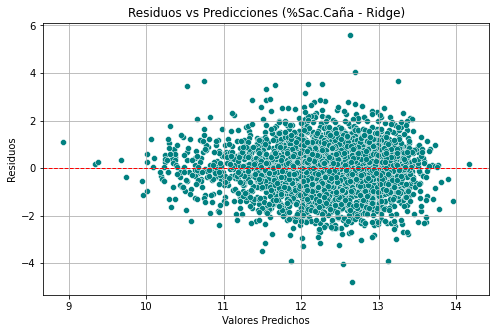

In [ ]:
# 5.1 Gráfico de residuos vs predicciones RIDGE

# arrays planos y del mismo tipo
y_test_sac_array = np.array(y_test, dtype='float64').flatten()
y_pred_sac_array = np.array(y_pred_ridge, dtype='float64').flatten()

# Calcular residuos
residuos_sac = y_test_sac_array - y_pred_sac_array

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_sac_array, y=residuos_sac, color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuos vs Predicciones (%Sac.Caña - Ridge)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()

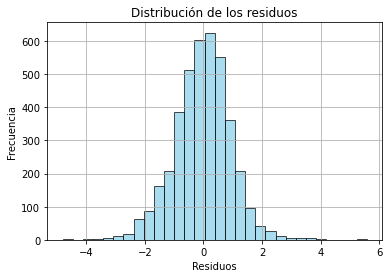

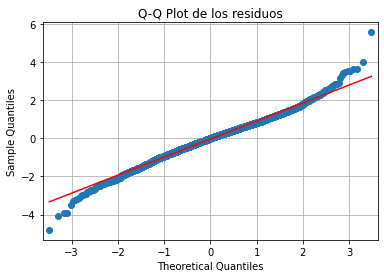

In [ ]:
#5.2 Histograma y Q-Q plot de residuos (normalidad)

plt.figure(figsize=(6, 4))
plt.hist(residuos_sac, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

sm.qqplot(residuos_sac, line='s')
plt.title("Q-Q Plot de los residuos")
plt.grid(True)
plt.show()

In [ ]:
# 6. LASSO sin polinomios + GridSearchCV

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_imputed, y_train)
y_pred_lasso = lasso_grid.best_estimator_.predict(X_test_imputed)


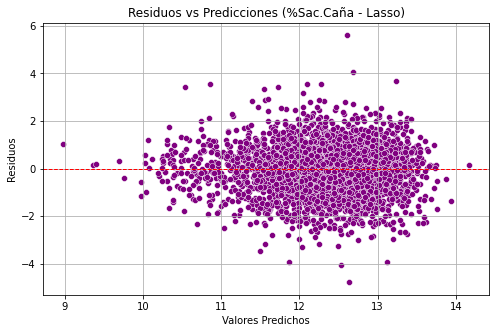

In [ ]:
# 6.1 Gráfico de residuos vs predicciones LASSO

# Convertir a arrays planos

y_test_sac_array = np.array(y_test, dtype='float64').flatten()
y_pred_sac_array = np.array(y_pred_lasso, dtype='float64').flatten()

# Calcular residuos
residuos_sac_lasso = y_test_sac_array - y_pred_sac_array

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_sac_array, y=residuos_sac_lasso, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuos vs Predicciones (%Sac.Caña - Lasso)")
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.grid(True)
plt.show()


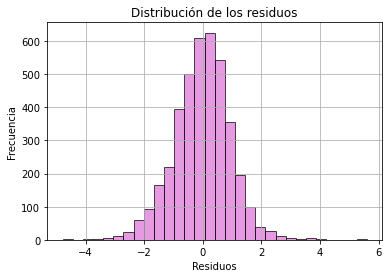

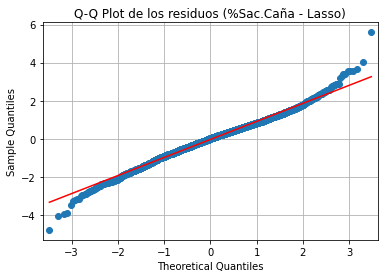

In [ ]:
# 6.2 Histograma y Q-Q plot de residuos (normalidad) LASSO

plt.figure(figsize=(6, 4))
plt.hist(residuos_sac_lasso, bins=30, color='orchid', edgecolor='black', alpha=0.7)
plt.title("Distribución de los residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

sm.qqplot(residuos_sac_lasso, line='s')
plt.title("Q-Q Plot de los residuos (%Sac.Caña - Lasso)")
plt.grid(True)
plt.show()



In [ ]:
# 7. Variables eliminadas por Lasso

variables_eliminadas_lasso = lasso_df[lasso_df["Coef_Lasso"] == 0].reset_index(drop=True)
print(f"\n=== Variables eliminadas por Lasso: {len(variables_eliminadas_lasso)} ===")
print(variables_eliminadas_lasso)



=== Variables eliminadas por Lasso: 34 ===
                                          Variable  Coef_Lasso  Abs_Lasso
0                                          dist_km        -0.0        0.0
1                                    cult_organico         0.0        0.0
2                                  edad_precosecha        -0.0        0.0
3                                            vejez        -0.0        0.0
4                                  dosis_madurante         0.0        0.0
5                                     semanas_mad_        -0.0        0.0
6                                      ddult_riego         0.0        0.0
7                                       num_riegos        -0.0        0.0
8                              lluvias_tres_a_seis        -0.0        0.0
9                                    lluvias_ciclo         0.0        0.0
10                                   m3_riego_p_ha         0.0        0.0
11                              algun_fertilizante         0.0      

In [ ]:
# 8. Coeficientes de Ridge y Lasso
# Crear lista de tuplas para Ridge
ridge_coef = [(var, coef) for var, coef in zip(X_train_imputed.columns, ridge_best.coef_)]
ridge_df = pd.DataFrame(ridge_coef, columns=["Variable", "Coef_Ridge"])
ridge_df["Abs_Ridge"] = np.abs(ridge_df["Coef_Ridge"])
ridge_df_sorted = ridge_df.sort_values(by="Abs_Ridge", ascending=False).reset_index(drop=True)

# Crear lista de tuplas para Lasso
lasso_coef = [(var, coef) for var, coef in zip(X_train_imputed.columns, lasso_best.coef_)]
lasso_df = pd.DataFrame(lasso_coef, columns=["Variable", "Coef_Lasso"])
lasso_df["Abs_Lasso"] = np.abs(lasso_df["Coef_Lasso"])
lasso_df_sorted = lasso_df.sort_values(by="Abs_Lasso", ascending=False).reset_index(drop=True)

# Mostrar los resultados
print("Coeficientes de Ridge (ordenados por magnitud)")
print(ridge_df_sorted[["Variable", "Coef_Ridge"]])

print("Coeficientes de Lasso (ordenados por magnitud)")
print(lasso_df_sorted[["Variable", "Coef_Lasso"]])


Coeficientes de Ridge (ordenados por magnitud)
                                          Variable  Coef_Ridge
0                                     edad_ult_cos    3.876596
1                                        zona_ip01   -3.255577
2                           edad_siembra_a_ult_cos   -2.723152
3                                     pct_sac_caña   -2.136548
4                                        zona_ip02    2.018077
5                        variedad_v2_cc_mayor_2000    1.772557
6                             lluvias_seis_a_nueve    1.321533
7                                        zona_ip03    1.272403
8                               variedad_v2_others   -1.187621
9                   rango_edad_ult_cos_11-12 meses   -1.187443
10                                 t_corte_no_def_    1.108746
11                                 lluvias_9_a_cos    0.994783
12                                  t_corte_manual   -0.970008
13                         tipo_quema_q_accidental   -0.910035
14      

In [ ]:
# 9. POLYNOMIAL FEATURES (grado 2)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_imputed)
X_test_poly = poly.transform(X_test_imputed)

In [ ]:
# 10. RIDGE + Polynomial + GridSearchCV

ridge_poly_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_poly_grid.fit(X_train_poly, y_train)
y_pred_poly_ridge = ridge_poly_grid.best_estimator_.predict(X_test_poly)


In [ ]:
# 11. LASSO + Polynomial + GridSearchCV

lasso_poly_grid = GridSearchCV(Lasso(max_iter=100), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_poly_grid.fit(X_train_poly, y_train)
y_pred_poly_lasso = lasso_poly_grid.best_estimator_.predict(X_test_poly)


In [ ]:
# 12. COMPARACIÓN FINAL

def evaluar_modelo(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }

resultados = [
    evaluar_modelo("Ridge", y_test, y_pred_ridge),
    evaluar_modelo("Lasso", y_test, y_pred_lasso),
    evaluar_modelo("Ridge + Poly", y_test, y_pred_poly_ridge),
    evaluar_modelo("Lasso + Poly", y_test, y_pred_poly_lasso)
]

df_resultados_pct_sac = pd.DataFrame(resultados).sort_values(by="R²", ascending=False).reset_index(drop=True)
print(df_resultados_pct_sac)


         Modelo       MAE      RMSE        R²
0  Lasso + Poly  0.693198  0.908099  0.360801
1  Ridge + Poly  0.692568  0.908526  0.360201
2         Lasso  0.732168  0.948103  0.303244
3         Ridge  0.731765  0.948132  0.303202
